# Run comparison

Configure labeled reward groups below. Each group may contain one aggregate run or several exact `.npz` or legacy `.npy` files. Relative paths are resolved from the repository root.

In [ ]:
RUNS = {
    "NPG 4x4": ["runs/HalfCheetah/npg/4x4"],
    "NPG 8x8": ["runs/HalfCheetah/npg/8x8"],
    "NPG 16x16": ["runs/HalfCheetah/npg/16x16"],
}

MEAN_TITLE = "HalfCheetah network-width comparison"
BEST_TITLE = "HalfCheetah best-seed comparison"
XLABEL = "Iteration"
YLABEL = "Average training return"
MEAN_OUTPUT = "runs/HalfCheetah/comparison.png"
BEST_OUTPUT = "runs/HalfCheetah/best_seed_comparison.png"
FINAL_WINDOW = 100

In [ ]:
import sys
from pathlib import Path

import numpy as np
from IPython.display import Image, display

working_dir = Path.cwd().resolve()
repo_root = next(
    (path for path in (working_dir, *working_dir.parents) if (path / "analysis.py").is_file()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Could not locate the repository root containing analysis.py")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from vpg.analysis import load_reward_files, plot_comparison

def from_repo_root(path):
    path = Path(path).expanduser()
    return path.resolve() if path.is_absolute() else (repo_root / path).resolve()

NPG 4x4:
  source: C:\Users\andre\OneDrive\Desktop\Exams\RL\MP\vanilla-policy-gradient\runs\HalfCheetah\NPG\4x4\training_rewards.npz
  curves: 1
  seeds: [23]
  best seed: 23
NPG 8x8:
  source: C:\Users\andre\OneDrive\Desktop\Exams\RL\MP\vanilla-policy-gradient\runs\HalfCheetah\NPG\8x8\training_rewards.npz
  curves: 1
  seeds: [23]
  best seed: 23
NPG 16x16:
  source: C:\Users\andre\OneDrive\Desktop\Exams\RL\MP\vanilla-policy-gradient\runs\HalfCheetah\NPG\16x16\training_rewards.npz
  curves: 1
  seeds: [23]
  best seed: 23
saved mean comparison: C:\Users\andre\OneDrive\Desktop\Exams\RL\MP\vanilla-policy-gradient\runs\HalfCheetah\comparison.png


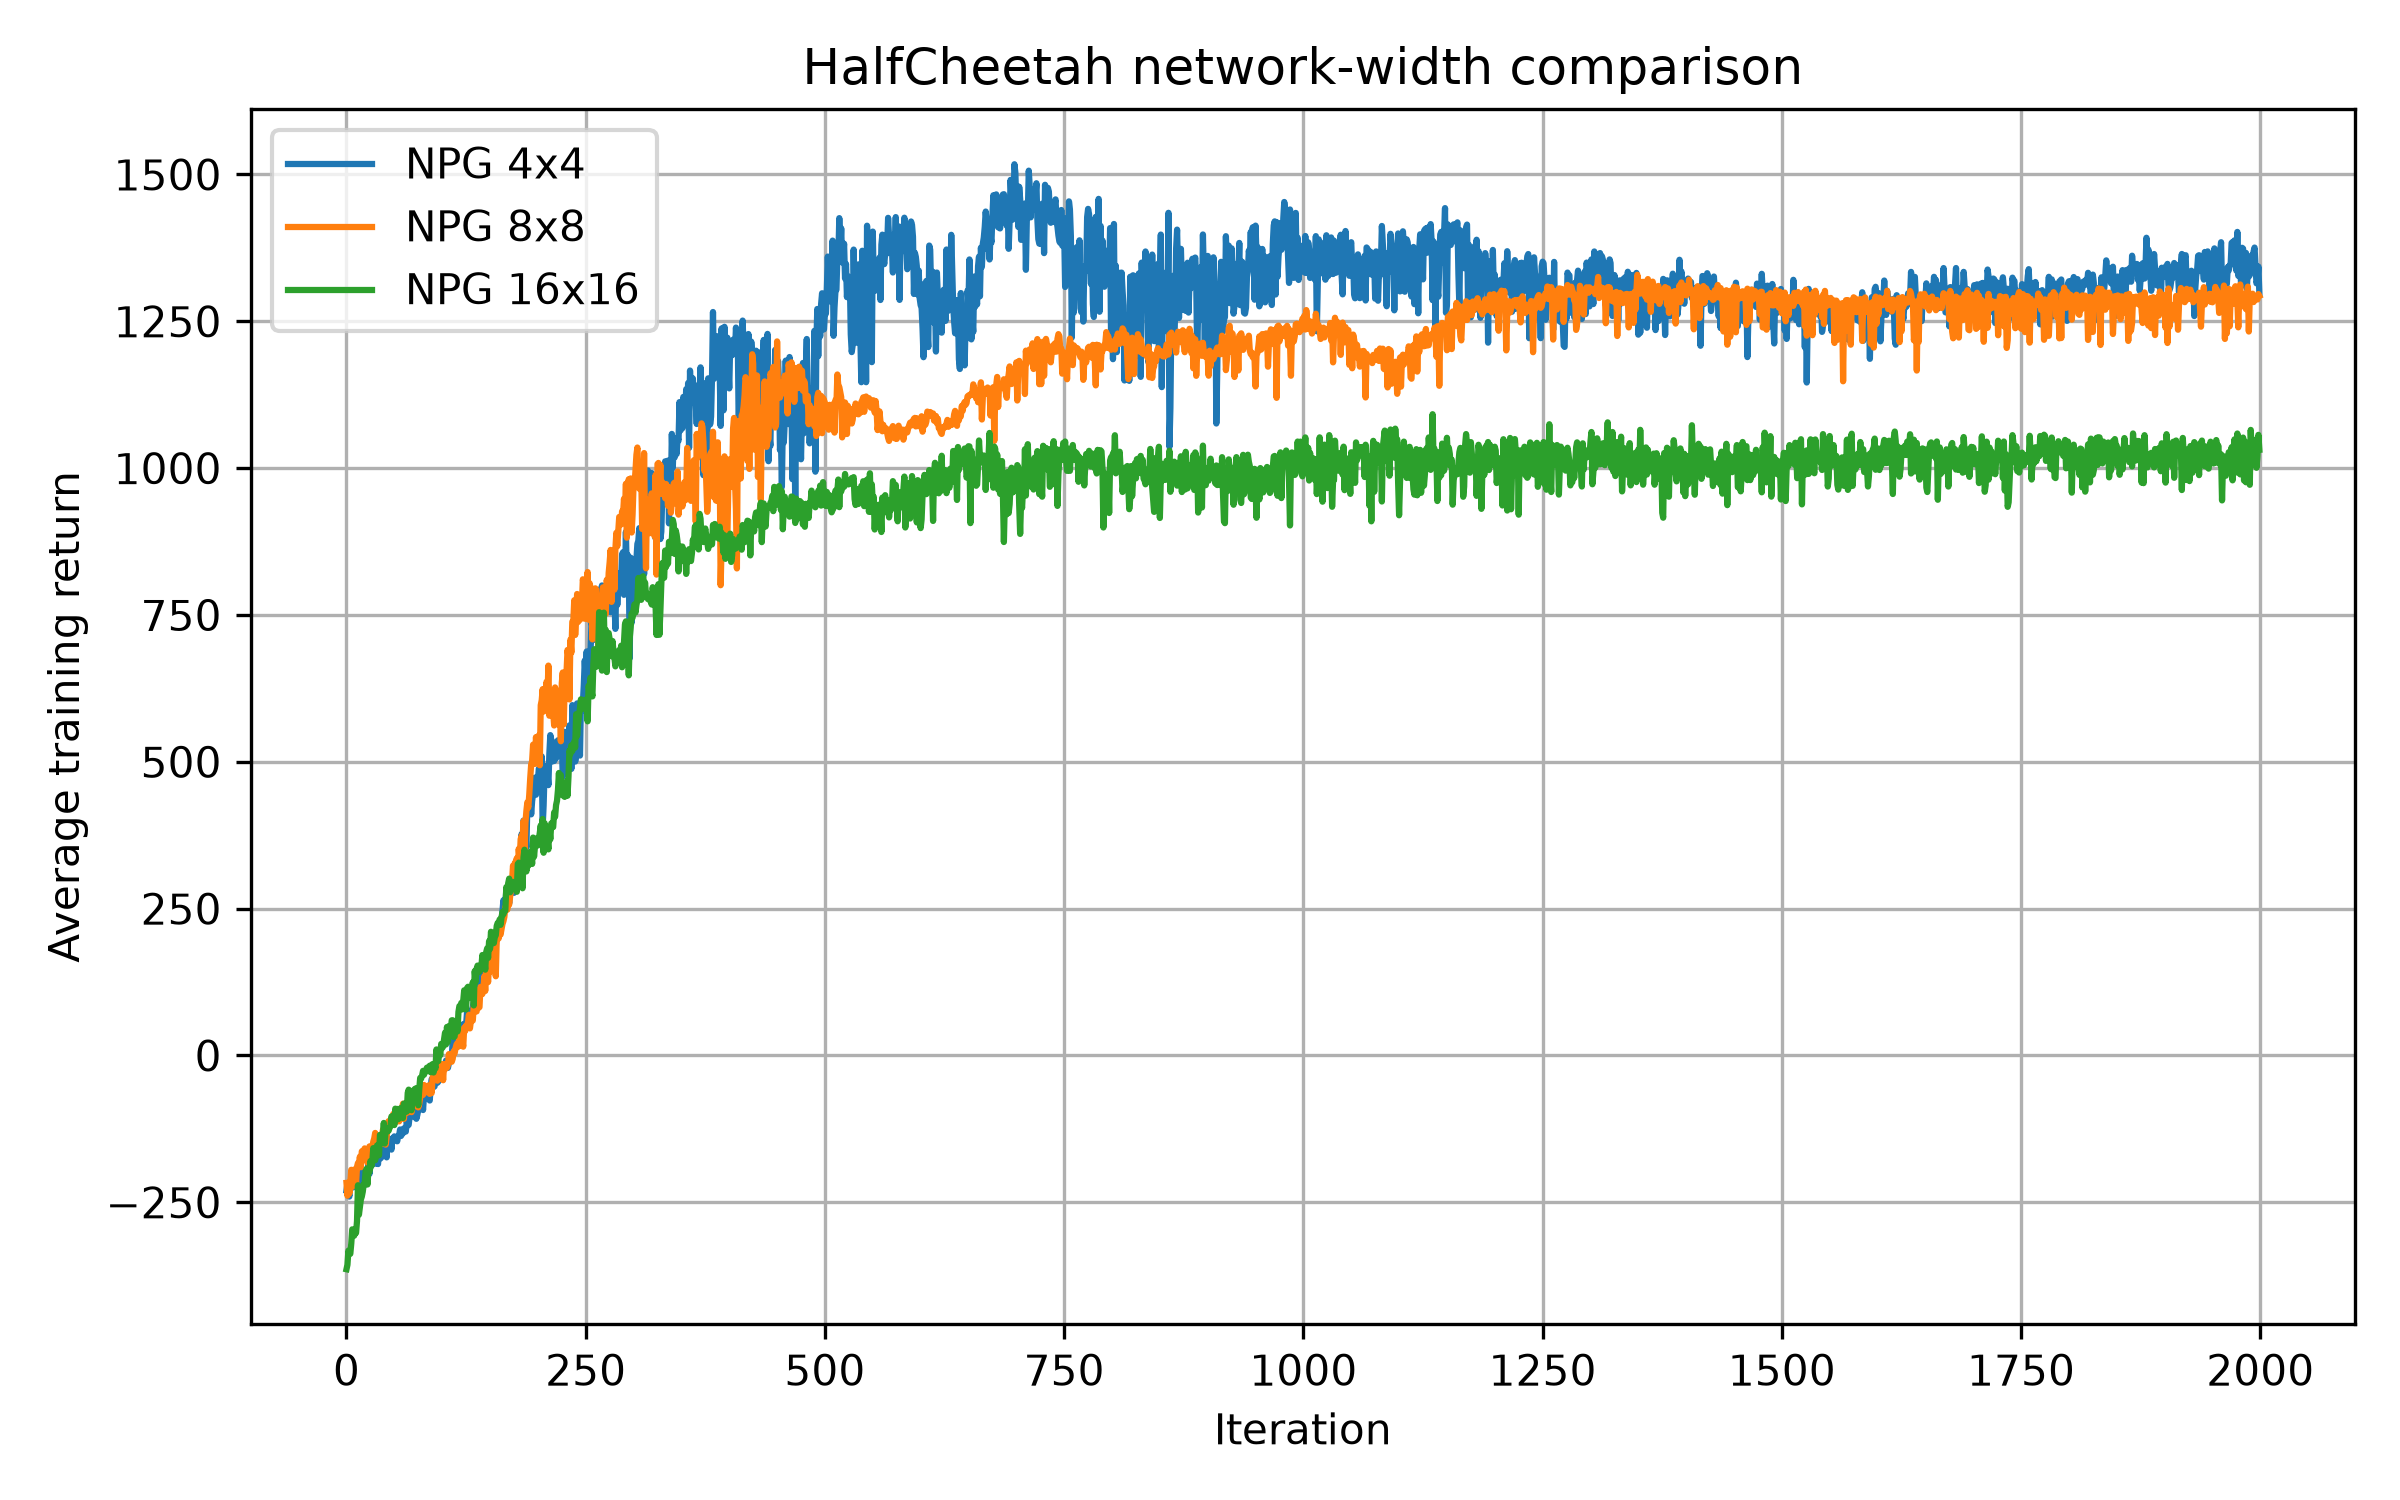

saved best-seed comparison: C:\Users\andre\OneDrive\Desktop\Exams\RL\MP\vanilla-policy-gradient\runs\HalfCheetah\best_seed_comparison.png


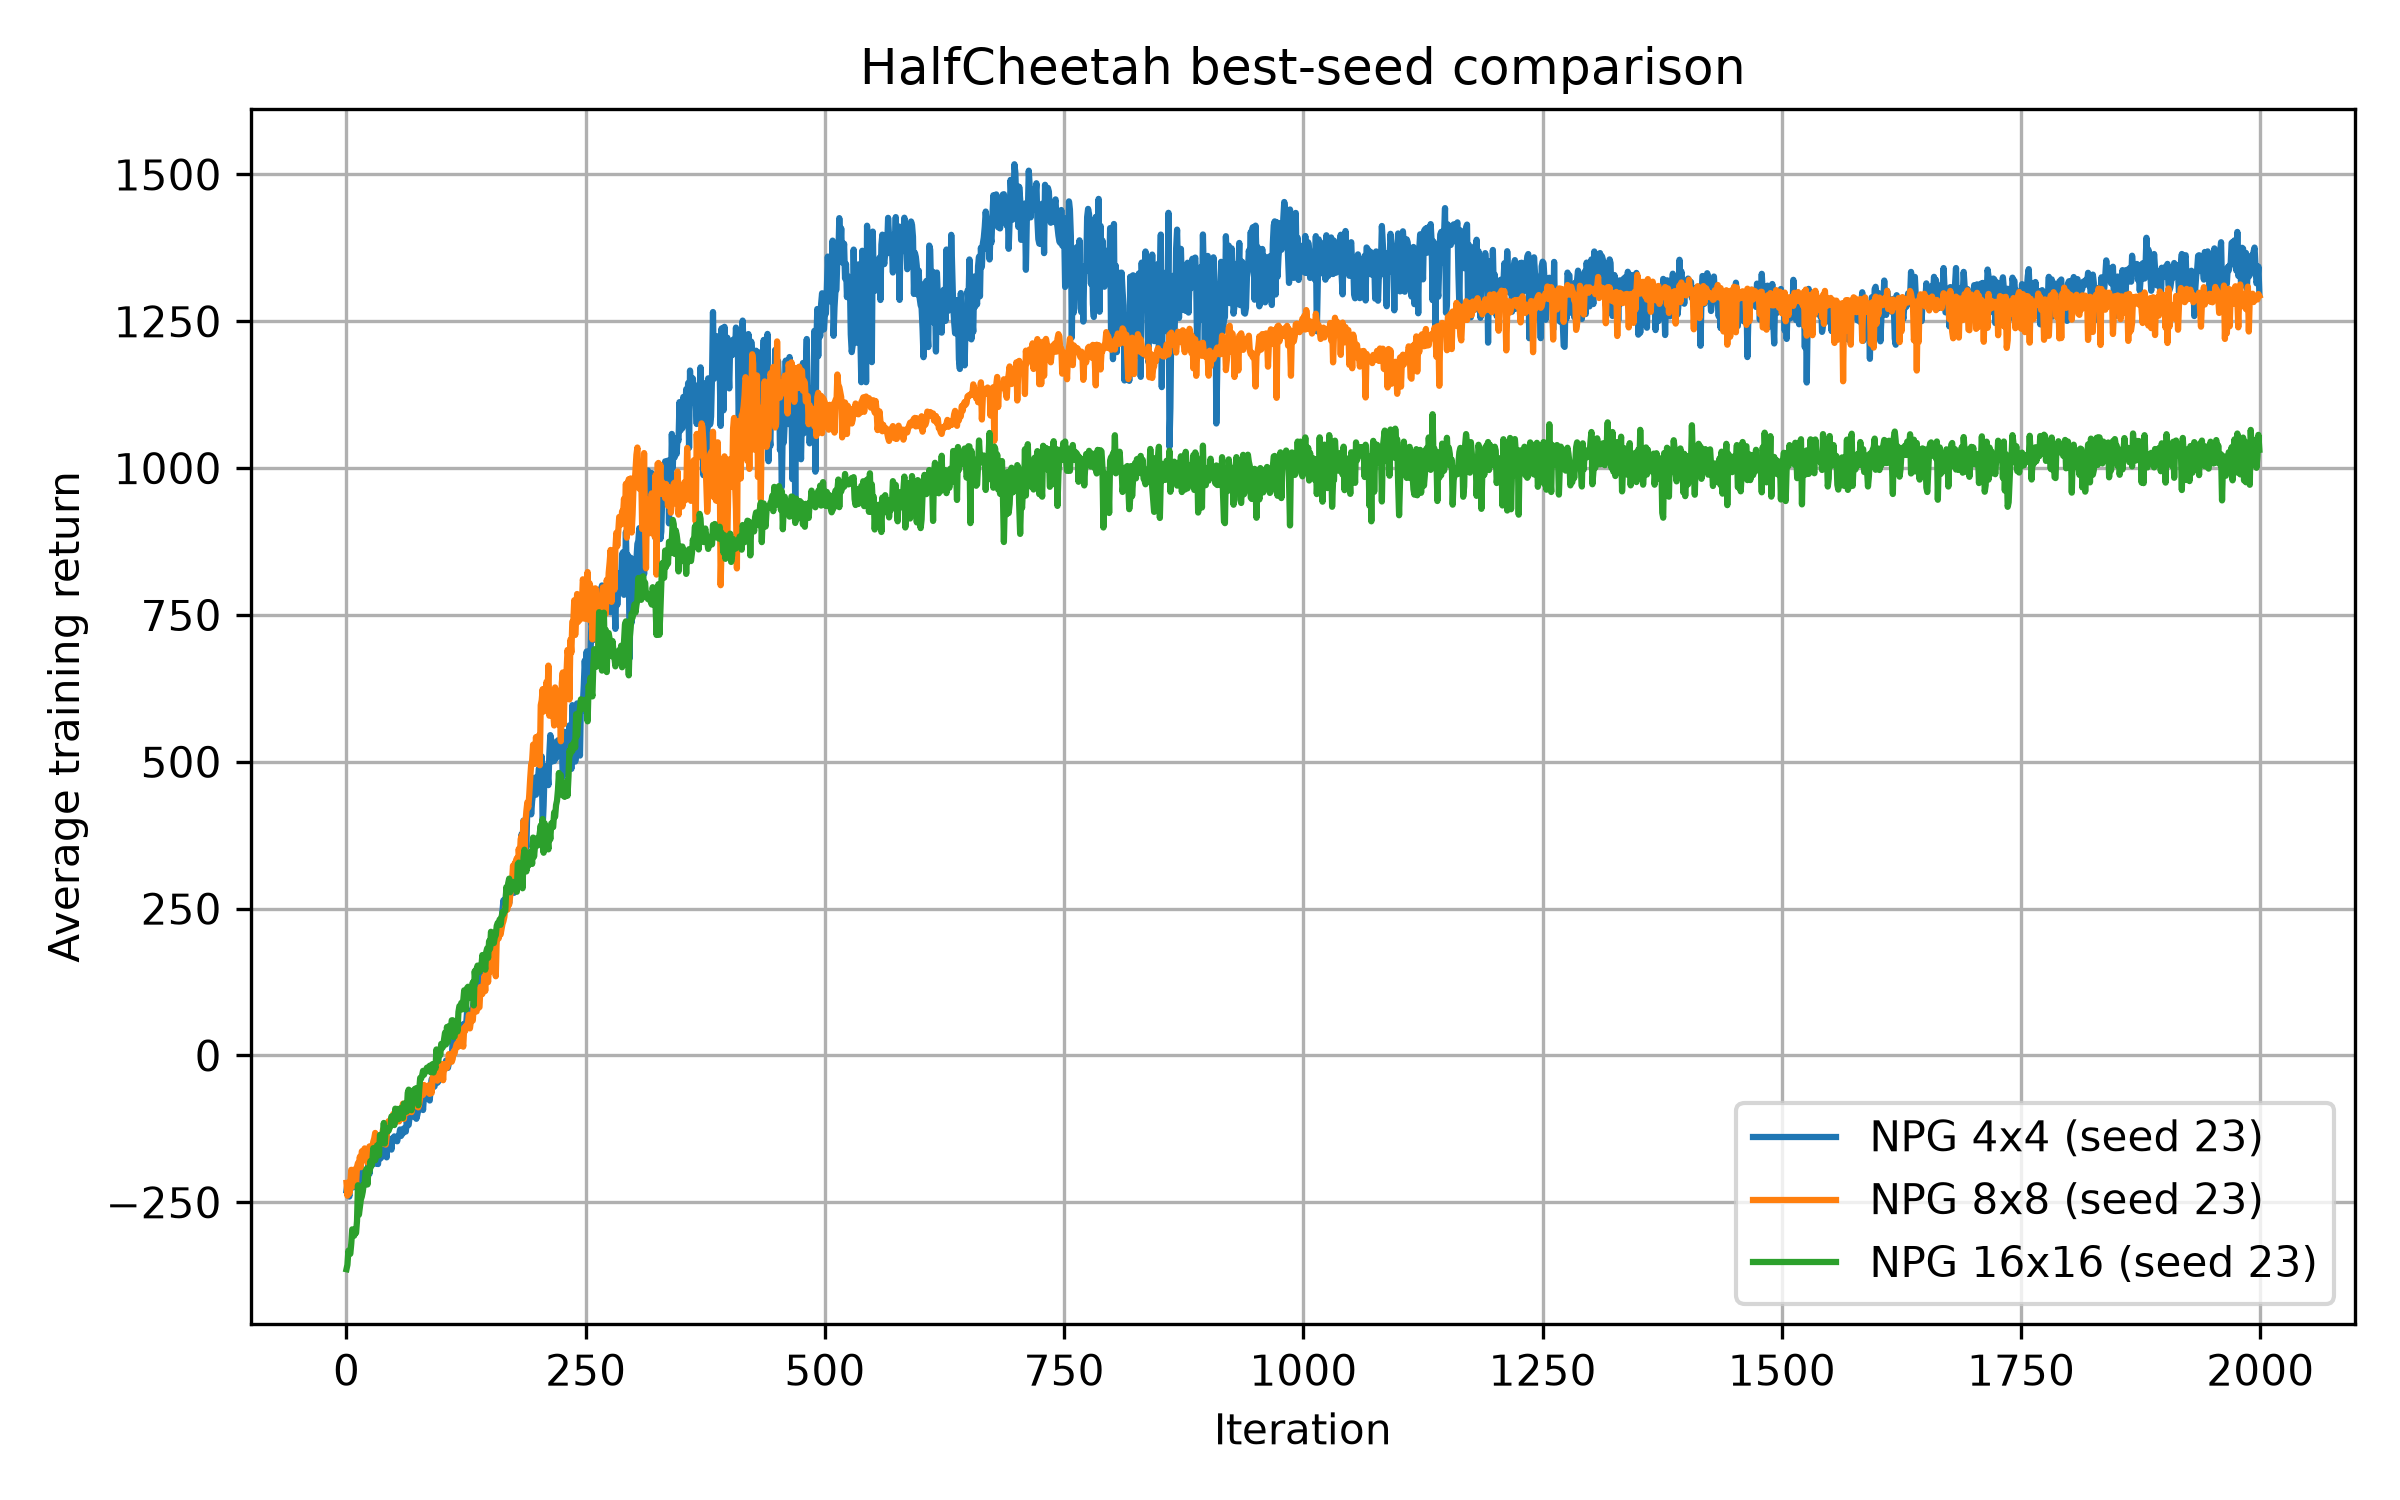

In [3]:
if FINAL_WINDOW <= 0:
    raise ValueError("FINAL_WINDOW must be greater than zero")

groups = {
    label: load_reward_files([from_repo_root(path) for path in inputs])
    for label, inputs in RUNS.items()
}

for label, data in groups.items():
    seed_ids = data.seeds.tolist() if data.seeds is not None else "not stored"
    window = min(FINAL_WINDOW, data.curves.shape[1])
    best_index = int(np.argmax(data.curves[:, -window:].mean(axis=1)))
    best_seed = data.seeds[best_index] if data.seeds is not None else data.labels[best_index]
    print(f"{label}:")
    for source in data.sources:
        print(f"  source: {source}")
    print(f"  curves: {len(data.curves)}")
    print(f"  seeds: {seed_ids}")
    print(f"  best seed: {best_seed}")

mean_path = plot_comparison(
    groups,
    from_repo_root(MEAN_OUTPUT),
    title=MEAN_TITLE,
    xlabel=XLABEL,
    ylabel=YLABEL,
    mode="mean",
    final_window=FINAL_WINDOW,
)
best_path = plot_comparison(
    groups,
    from_repo_root(BEST_OUTPUT),
    title=BEST_TITLE,
    xlabel=XLABEL,
    ylabel=YLABEL,
    mode="best",
    final_window=FINAL_WINDOW,
)

print(f"saved mean comparison: {mean_path}")
display(Image(filename=str(mean_path)))
print(f"saved best-seed comparison: {best_path}")
display(Image(filename=str(best_path)))